SARIMA FORECASTING FOR BRAZIL'S GDP PER CAPITA

✓ Data loaded: 135 records (1890-2024)
✓ GDP series range: 1890 - 2024
✓ GDP values range: $1099.00 - $15800.04

STEP 1: STATIONARITY ANALYSIS

DIFFERENCING ANALYSIS

Original series (d=0):

ADF Test for GDP per capita (d=0)
ADF Statistic: 0.892981
p-value: 0.992998
Critical Values:
	1%: -3.481
	5%: -2.884
	10%: -2.579
✗ Conclusion: GDP per capita (d=0) is NON-STATIONARY (fail to reject H0)

After differencing (d=1):

ADF Test for GDP per capita (d=1)
ADF Statistic: -5.582156
p-value: 0.000001
Critical Values:
	1%: -3.481
	5%: -2.884
	10%: -2.579
✓ Conclusion: GDP per capita (d=1) is STATIONARY (reject H0)

>>> Optimal differencing order: d = 1

STEP 2: SARIMA GRID SEARCH

GRID SEARCH FOR SARIMA PARAMETERS
Total combinations to test: 144
Non-seasonal (p,d,q): [0, 1, 2, 3] x [1] x [0, 1, 2, 3]
Seasonal (P,D,Q,s): [0, 1, 2] x [1] x [0, 1, 2] x [12]
------------------------------------------------------------
✓ New best model: SARIMA(0,1,0)(

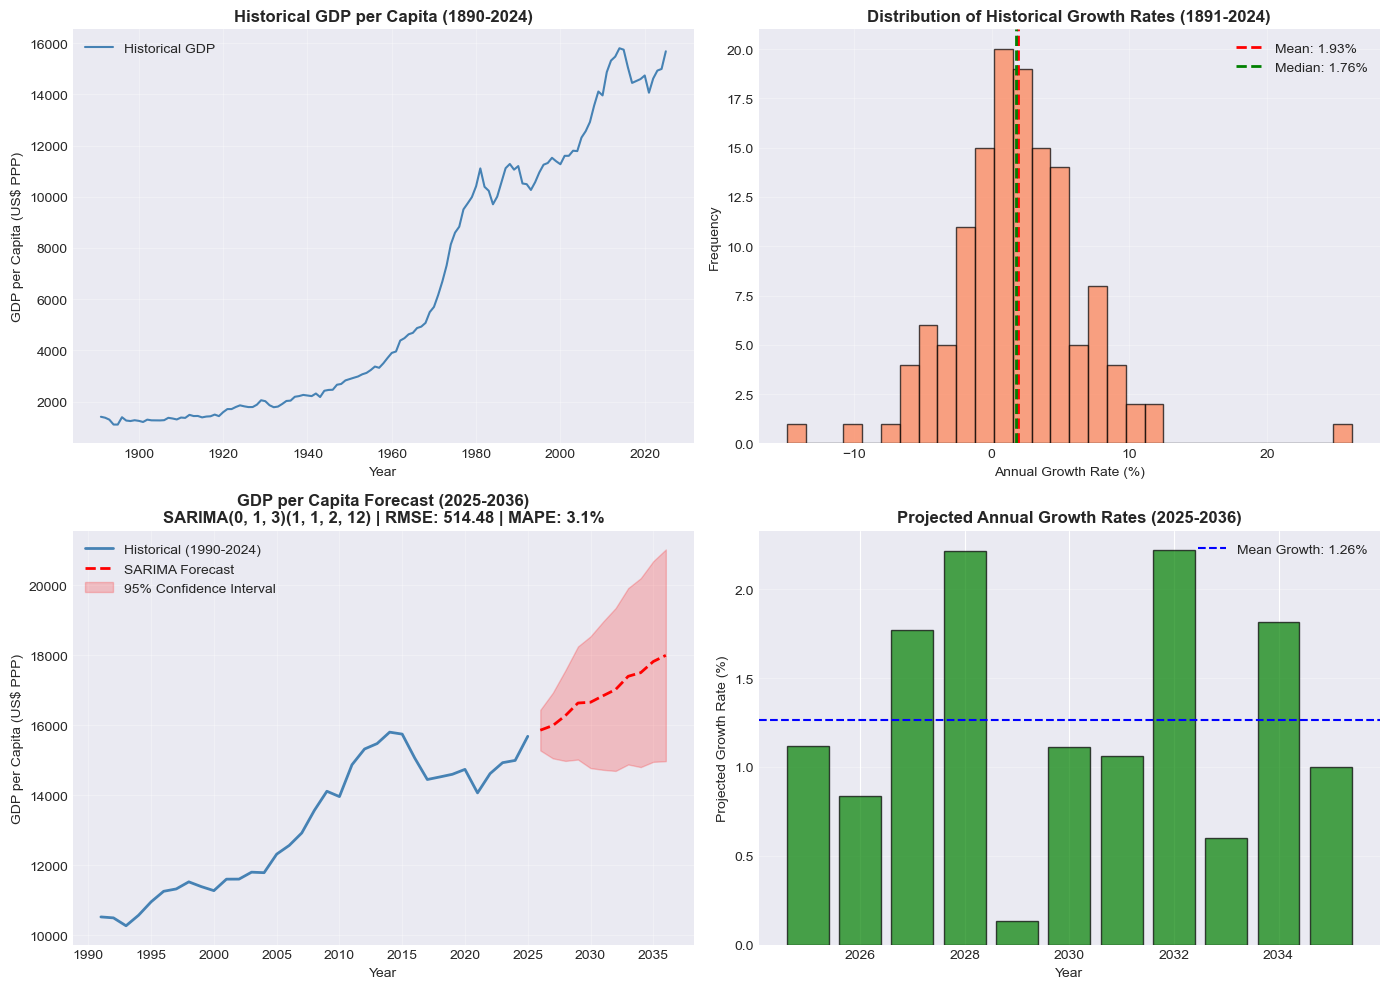


GROWTH RATES FOR GAMA MODEL (2025-2036)

// Projected GDP per capita growth rates for Brazil (2025-2036)
// Source: SARIMA time series model based on historical data (1890-2024)
// Model: SARIMA(0, 1, 3)(1, 1, 2, 12)
// Validation RMSE: 514.48, MAPE: 3.08%

list<float> pib_per_capita_crescimento_brasil <- [
    0.011194, // 2025
    0.008365, // 2026
    0.017716, // 2027
    0.022153, // 2028
    0.001347, // 2029
    0.011121, // 2030
    0.010602, // 2031
    0.022184, // 2032
    0.006014, // 2033
    0.018149, // 2034
    0.009987, // 2035
];

✓ GAMA-ready CSV saved: ..\resultados\gama_growth_rates_2025_2036.csv

PROCESS COMPLETED SUCCESSFULLY!


In [2]:
"""
================================================================================
SCRIPT: SARIMA FORECASTING OF BRAZIL'S GDP PER CAPITA (2025-2036)
================================================================================
Author: Model Calibration Script
Purpose: Project GDP per capita growth rates using SARIMA time series model
Data Source: Historical GDP per capita (PPP) data for Brazil (1890-2024)
Reference: World Economics / Historical economic data

Methodology:
- Automatic grid search for optimal SARIMA parameters (p,d,q)(P,D,Q,s)
- Selection criteria: Minimum AIC (Akaike Information Criterion)
- Differencing analysis to ensure stationarity (ADF test)
- 12-year forecast (2025-2036) with confidence intervals
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
from itertools import product
import os

warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")

# ============================================================================
# 1. CONFIGURATION AND DATA LOADING
# ============================================================================

# Configuration
BASE_PATH = '..'
INPUT_FILENAME = 'PIB_Serie_Historica_World_Economics.csv'
OUTPUT_PATH = os.path.join(BASE_PATH, 'resultados')
FORECAST_HORIZON = 11  # Years: 2025 to 2035
TEST_YEARS = 5  # Last 5 years for validation (2012020-2024)

# Create output directory if it doesn't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)

def load_data(file_path):
    """Load GDP per capita data from CSV file"""
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
    # Use comma as decimal separator and semicolon as field separator
    df = pd.read_csv(file_path, sep=';', decimal=',')
    return df

def prepare_time_series(df):
    """Prepare time series with proper datetime index"""
    # Convert to datetime and set as index
    df['Data'] = pd.to_datetime(df['Ano'].astype(str) + '-12-31')
    df = df.set_index('Data').sort_index()
    
    # Extract GDP values (use the numeric column without thousand separators)
    # The GDP column already has dots as thousand separators, but pandas reads as string
    # Let's clean it
    gdp_series = df['GDP (U$)'].copy()
    
    # If it's string, convert to float (handling thousand separators)
    if gdp_series.dtype == 'object':
        gdp_series = gdp_series.str.replace('.', '', regex=False).str.replace(',', '.').astype(float)
    
    return gdp_series

# ============================================================================
# 2. STATIONARITY ANALYSIS AND DIFFERENCING
# ============================================================================

def check_stationarity(series, series_name="Series"):
    """
    Augmented Dickey-Fuller test for stationarity
    H0: Series is non-stationary (has unit root)
    H1: Series is stationary
    """
    # Drop NaN values
    series_clean = series.dropna()
    
    if len(series_clean) < 3:
        print(f"Warning: Insufficient data for ADF test on {series_name}")
        return False
    
    result = adfuller(series_clean, autolag='AIC')
    print(f"\n{'='*60}")
    print(f"ADF Test for {series_name}")
    print(f"{'='*60}")
    print(f'ADF Statistic: {result[0]:.6f}')
    print(f'p-value: {result[1]:.6f}')
    print(f'Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.3f}')
    
    if result[1] <= 0.05:
        print(f"✓ Conclusion: {series_name} is STATIONARY (reject H0)")
        return True
    else:
        print(f"✗ Conclusion: {series_name} is NON-STATIONARY (fail to reject H0)")
        return False

def find_optimal_differencing(series, max_diff=3):
    """Find optimal differencing order using ADF test"""
    series_diff = series.copy()
    optimal_d = 0
    
    print(f"\n{'='*60}")
    print(f"DIFFERENCING ANALYSIS")
    print(f"{'='*60}")
    
    # Original series
    print(f"\nOriginal series (d=0):")
    is_stationary = check_stationarity(series_diff, f"GDP per capita (d=0)")
    
    if is_stationary:
        print(f"\n>>> Series is already stationary. Optimal differencing: d = 0")
        return 0
    
    for d in range(1, max_diff + 1):
        series_diff = series_diff.diff().dropna()
        print(f"\nAfter differencing (d={d}):")
        is_stationary = check_stationarity(series_diff, f"GDP per capita (d={d})")
        if is_stationary:
            optimal_d = d
            print(f"\n>>> Optimal differencing order: d = {d}")
            break
    
    return optimal_d

# ============================================================================
# 3. SARIMA MODEL SELECTION (GRID SEARCH)
# ============================================================================

def sarima_grid_search(series, d, seasonal=True, verbose=True):
    """
    Grid search for optimal SARIMA parameters (p,d,q)(P,D,Q,s)
    Selection criteria: Minimum AIC
    """
    # Define parameter ranges
    p = q = range(0, 4)  # Non-seasonal AR and MA orders
    P = Q = range(0, 3)  # Seasonal AR and MA orders
    D = 1  # Seasonal differencing (typically 1 for annual data)
    s = 12  # Seasonal period (12 for monthly, 1 for annual - adjust as needed)
    
    # For annual data, seasonal component may not be necessary
    if not seasonal:
        P = Q = [0]
        D = 0
    
    # Generate all combinations
    non_seasonal_params = list(product(p, [d], q))
    seasonal_params = list(product(P, [D], Q, [s])) if seasonal else [(0, 0, 0, 0)]
    
    best_aic = float('inf')
    best_params = None
    best_model = None
    results = []
    
    total_combinations = len(non_seasonal_params) * len(seasonal_params)
    print(f"\n{'='*60}")
    print(f"GRID SEARCH FOR SARIMA PARAMETERS")
    print(f"{'='*60}")
    print(f"Total combinations to test: {total_combinations}")
    print(f"Non-seasonal (p,d,q): {list(p)} x [{d}] x {list(q)}")
    if seasonal:
        print(f"Seasonal (P,D,Q,s): {list(P)} x [{D}] x {list(Q)} x [{s}]")
    print(f"{'-'*60}")
    
    for (p_val, d_val, q_val), (P_val, D_val, Q_val, s_val) in product(non_seasonal_params, seasonal_params):
        try:
            model = SARIMAX(series, 
                           order=(p_val, d_val, q_val),
                           seasonal_order=(P_val, D_val, Q_val, s_val),
                           enforce_stationarity=False,
                           enforce_invertibility=False)
            model_fit = model.fit(disp=False)
            aic = model_fit.aic
            
            results.append({
                'p': p_val, 'd': d_val, 'q': q_val,
                'P': P_val, 'D': D_val, 'Q': Q_val, 's': s_val,
                'AIC': aic
            })
            
            if aic < best_aic:
                best_aic = aic
                best_params = (p_val, d_val, q_val, P_val, D_val, Q_val, s_val)
                best_model = model_fit
                if verbose:
                    print(f"✓ New best model: SARIMA({p_val},{d_val},{q_val})({P_val},{D_val},{Q_val},{s_val}) - AIC: {aic:.2f}")
            else:
                if verbose and total_combinations <= 100:
                    print(f"  Tested: SARIMA({p_val},{d_val},{q_val})({P_val},{D_val},{Q_val},{s_val}) - AIC: {aic:.2f}")
                    
        except Exception as e:
            continue
    
    # Sort results by AIC
    results_df = pd.DataFrame(results).sort_values('AIC')
    
    print(f"\n{'='*60}")
    print(f"BEST MODEL SELECTED")
    print(f"{'='*60}")
    print(f"SARIMA{best_params[:3]}{best_params[3:7]} - AIC: {best_aic:.2f}")
    
    return best_model, best_params, results_df

# ============================================================================
# 4. MODEL DIAGNOSTICS
# ============================================================================

def model_diagnostics(model_fit):
    """Print model diagnostic information"""
    print(f"\n{'='*60}")
    print(f"MODEL DIAGNOSTICS")
    print(f"{'='*60}")
    print(model_fit.summary())
    
    # Residual analysis
    residuals = model_fit.resid
    print(f"\nResidual Statistics:")
    print(f"Mean: {residuals.mean():.6f}")
    print(f"Std Dev: {residuals.std():.6f}")
    print(f"Skewness: {residuals.skew():.4f}")
    print(f"Kurtosis: {residuals.kurtosis():.4f}")

# ============================================================================
# 5. FORECASTING
# ============================================================================

def forecast_future(model_fit, steps, series, start_year):
    """Generate future forecasts with confidence intervals"""
    forecast_result = model_fit.get_forecast(steps=steps)
    forecast_mean = forecast_result.predicted_mean
    forecast_ci = forecast_result.conf_int()
    
    # Create forecast index (years)
    last_year = start_year - 1
    forecast_years = [last_year + i + 1 for i in range(steps)]
    
    # Calculate projected growth rates
    last_actual = series.iloc[-1]
    projected_growth = []
    
    for i, value in enumerate(forecast_mean.values):
        if i == 0:
            growth = (value - last_actual) / last_actual
        else:
            growth = (value - forecast_mean.values[i-1]) / forecast_mean.values[i-1]
        projected_growth.append(growth)
    
    # Create DataFrame
    forecast_df = pd.DataFrame({
        'Ano': forecast_years,
        'GDP_per_capita_projetado': forecast_mean.values,
        'IC_95%_inferior': forecast_ci.iloc[:, 0].values,
        'IC_95%_superior': forecast_ci.iloc[:, 1].values,
        '%_Crescimento_projetado': projected_growth
    })
    
    return forecast_df

# ============================================================================
# 6. BACKTESTING (VALIDATION)
# ============================================================================

def backtest_model(series, model_params, test_years=5):
    """
    Backtest the model using the last 'test_years' of data
    Returns RMSE and MAPE for validation
    """
    train = series.iloc[:-test_years]
    test = series.iloc[-test_years:]
    
    # Train model on training data
    p, d, q, P, D, Q, s = model_params
    model = SARIMAX(train, 
                    order=(p, d, q),
                    seasonal_order=(P, D, Q, s),
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    model_fit = model.fit(disp=False)
    
    # Forecast
    forecast = model_fit.forecast(steps=test_years)
    
    # Calculate errors
    errors = test.values - forecast.values
    rmse = np.sqrt(np.mean(errors**2))
    mape = np.mean(np.abs(errors / test.values)) * 100
    
    print(f"\n{'='*60}")
    print(f"BACKTESTING RESULTS (Validation Period: {test_years} years)")
    print(f"{'='*60}")
    print(f"RMSE: {rmse:.2f} (US$ PPP)")
    print(f"MAPE: {mape:.2f}%")
    
    # Print year-by-year comparison
    print(f"\nYear-by-year comparison:")
    print(f"{'Year':<6} {'Actual':<12} {'Forecast':<12} {'Error %':<10}")
    print(f"{'-'*45}")
    for year, actual, pred in zip(test.index.year, test.values, forecast.values):
        error_pct = (pred - actual) / actual * 100
        print(f"{year:<6} {actual:<12.2f} {pred:<12.2f} {error_pct:<10.2f}%")
    
    return rmse, mape, forecast, test

# ============================================================================
# 7. VISUALIZATION
# ============================================================================

def create_visualization(historical_series, forecast_df, model_params, rmse, mape):
    """Create comprehensive visualization of historical data and forecast"""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Historical GDP per capita (Full series)
    ax1 = axes[0, 0]
    ax1.plot(historical_series.index, historical_series.values, 
             color='steelblue', linewidth=1.5, label='Historical GDP')
    ax1.set_title('Historical GDP per Capita (1890-2024)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('GDP per Capita (US$ PPP)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Growth Rate Distribution
    ax2 = axes[0, 1]
    growth_rates = historical_series.pct_change().dropna() * 100
    ax2.hist(growth_rates, bins=30, color='coral', edgecolor='black', alpha=0.7)
    ax2.axvline(growth_rates.mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {growth_rates.mean():.2f}%')
    ax2.axvline(growth_rates.median(), color='green', linestyle='--', 
                linewidth=2, label=f'Median: {growth_rates.median():.2f}%')
    ax2.set_title('Distribution of Historical Growth Rates (1891-2024)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Annual Growth Rate (%)')
    ax2.set_ylabel('Frequency')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Recent history + Forecast (1990-2036)
    ax3 = axes[1, 0]
    recent_mask = historical_series.index >= pd.Timestamp('1990-12-31')
    recent_historical = historical_series[recent_mask]
    
    ax3.plot(recent_historical.index, recent_historical.values, 
             color='steelblue', linewidth=2, label='Historical (1990-2024)')
    
    forecast_years = pd.to_datetime(forecast_df['Ano'].astype(str) + '-12-31')
    ax3.plot(forecast_years, forecast_df['GDP_per_capita_projetado'], 
             color='red', linewidth=2, linestyle='--', label='SARIMA Forecast')
    
    ax3.fill_between(forecast_years, 
                     forecast_df['IC_95%_inferior'], 
                     forecast_df['IC_95%_superior'], 
                     color='red', alpha=0.2, label='95% Confidence Interval')
    
    ax3.set_title(f'GDP per Capita Forecast (2025-2036)\nSARIMA{model_params[:3]}{model_params[3:7]} | RMSE: {rmse:.2f} | MAPE: {mape:.1f}%', 
                  fontsize=12, fontweight='bold')
    ax3.set_xlabel('Year')
    ax3.set_ylabel('GDP per Capita (US$ PPP)')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: Forecasted Growth Rates
    ax4 = axes[1, 1]
    forecast_growth = forecast_df['%_Crescimento_projetado'] * 100
    colors = ['green' if x >= 0 else 'red' for x in forecast_growth]
    bars = ax4.bar(forecast_df['Ano'], forecast_growth, 
                   color=colors, alpha=0.7, edgecolor='black')
    ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax4.axhline(y=forecast_growth.mean(), color='blue', linestyle='--', 
                linewidth=1.5, label=f'Mean Growth: {forecast_growth.mean():.2f}%')
    ax4.set_title('Projected Annual Growth Rates (2025-2036)', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Projected Growth Rate (%)')
    ax4.legend()
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save figure
    fig_path = os.path.join(OUTPUT_PATH, 'sarima_gdp_forecast.png')
    plt.savefig(fig_path, dpi=300, bbox_inches='tight')
    print(f"\nFigure saved: {fig_path}")
    
    plt.show()
    
    return fig

# ============================================================================
# 8. EXPORT RESULTS FOR GAMA
# ============================================================================

def export_for_gama(forecast_df, model_params, rmse, mape):
    """Export results in formats ready for GAMA model"""
    
    # Extract growth rates for GAMA
    growth_rates = forecast_df['%_Crescimento_projetado'].values
    
    print("\n" + "="*80)
    print("GROWTH RATES FOR GAMA MODEL (2025-2036)")
    print("="*80)
    print("\n// Projected GDP per capita growth rates for Brazil (2025-2036)")
    print("// Source: SARIMA time series model based on historical data (1890-2024)")
    print(f"// Model: SARIMA{model_params[:3]}{model_params[3:7]}")
    print(f"// Validation RMSE: {rmse:.2f}, MAPE: {mape:.2f}%\n")
    
    print("list<float> pib_per_capita_crescimento_brasil <- [")
    for i, rate in enumerate(growth_rates):
        year = 2025 + i
        comma = "," if i < len(growth_rates) - 1 else ""
        print(f"    {rate:.6f}, // {year}")
    print("];")
    
    # Also export as CSV with proper format
    gama_export = forecast_df[['Ano', '%_Crescimento_projetado']].copy()
    gama_export['%_Crescimento_projetado'] = gama_export['%_Crescimento_projetado'].round(6)
    gama_export_path = os.path.join(OUTPUT_PATH, 'gama_growth_rates_2025_2036.csv')
    gama_export.to_csv(gama_export_path, sep=';', index=False, decimal=',')
    print(f"\n✓ GAMA-ready CSV saved: {gama_export_path}")

# ============================================================================
# 9. MAIN EXECUTION
# ============================================================================

def main():
    print("="*80)
    print("SARIMA FORECASTING FOR BRAZIL'S GDP PER CAPITA")
    print("="*80)
    
    # Load data
    input_path = os.path.join(BASE_PATH, 'includes','dados', INPUT_FILENAME)
    df = load_data(input_path)
    print(f"\n✓ Data loaded: {len(df)} records (1890-2024)")
    
    # Prepare time series
    gdp_series = prepare_time_series(df)
    print(f"✓ GDP series range: {gdp_series.index.min().year} - {gdp_series.index.max().year}")
    print(f"✓ GDP values range: ${gdp_series.min():.2f} - ${gdp_series.max():.2f}")
    
    # Check stationarity and find optimal differencing
    print("\n" + "="*80)
    print("STEP 1: STATIONARITY ANALYSIS")
    print("="*80)
    optimal_d = find_optimal_differencing(gdp_series, max_diff=2)
    
    # Grid search for optimal SARIMA parameters
    print("\n" + "="*80)
    print("STEP 2: SARIMA GRID SEARCH")
    print("="*80)
    
    # Try both seasonal and non-seasonal models
    best_model_seasonal, best_params_seasonal, results_seasonal = sarima_grid_search(
        gdp_series, optimal_d, seasonal=True, verbose=True
    )
    
    best_model_non_seasonal, best_params_non_seasonal, results_non_seasonal = sarima_grid_search(
        gdp_series, optimal_d, seasonal=False, verbose=True
    )
    
    # Compare AIC and select best model
    if best_model_seasonal.aic < best_model_non_seasonal.aic:
        best_model = best_model_seasonal
        best_params = best_params_seasonal
        print(f"\n✓ Selected SEASONAL model (AIC: {best_model.aic:.2f} vs {best_model_non_seasonal.aic:.2f})")
    else:
        best_model = best_model_non_seasonal
        best_params = best_params_non_seasonal
        print(f"\n✓ Selected NON-SEASONAL model (AIC: {best_model.aic:.2f} vs {best_model_seasonal.aic:.2f})")
    
    # Model diagnostics
    print("\n" + "="*80)
    print("STEP 3: MODEL DIAGNOSTICS")
    print("="*80)
    model_diagnostics(best_model)
    
    # Backtesting
    print("\n" + "="*80)
    print("STEP 4: MODEL VALIDATION (BACKTESTING)")
    print("="*80)
    rmse, mape, forecast_test, actual_test = backtest_model(gdp_series, best_params, TEST_YEARS)
    
    # Generate forecast
    print("\n" + "="*80)
    print(f"STEP 5: FORECASTING ({FORECAST_HORIZON} YEARS: 2025-2036)")
    print("="*80)
    forecast_df = forecast_future(best_model, FORECAST_HORIZON, gdp_series, start_year=2025)
    
    # Display forecast results
    print("\nFORECAST RESULTS:")
    print(forecast_df.to_string(index=False))
    
    # Save forecast to CSV
    forecast_path = os.path.join(OUTPUT_PATH, 'projecao_pib_per_capita_2025_2036.csv')
    forecast_df.to_csv(forecast_path, sep=';', index=False, decimal=',')
    print(f"\n✓ Forecast saved: {forecast_path}")
    
    # Save parameters
    params_df = pd.DataFrame({
        'parametro': ['modelo', 'p', 'd', 'q', 'P', 'D', 'Q', 's', 'rmse', 'mape', 'forecast_horizon'],
        'valor': [
            'SARIMA', best_params[0], best_params[1], best_params[2],
            best_params[3], best_params[4], best_params[5], best_params[6],
            rmse, mape, FORECAST_HORIZON
        ]
    })
    params_path = os.path.join(OUTPUT_PATH, 'sarima_model_params.csv')
    params_df.to_csv(params_path, sep=';', index=False)
    print(f"✓ Model parameters saved: {params_path}")
    
    # Create visualization
    print("\n" + "="*80)
    print("STEP 6: GENERATING VISUALIZATION")
    print("="*80)
    create_visualization(gdp_series, forecast_df, best_params, rmse, mape)
    
    # Export for GAMA
    export_for_gama(forecast_df, best_params, rmse, mape)
    
    print("\n" + "="*80)
    print("PROCESS COMPLETED SUCCESSFULLY!")
    print("="*80)
    
    return forecast_df, best_model, best_params

if __name__ == "__main__":
    forecast_df, best_model, best_params = main()